# What state is a market in, and what range of prices is plausible?

**In short.** Each market is labelled calm, normal or turbulent from its own prices,
using only what was known on the day. The label is about the present: it is found
after a rough stretch has begun and does not call turning points. From today's label,
10,000 possible futures are played out and the range they cover is reported. Whether
that range can be trusted is measured, not assumed: for every past day the same
simulation was run on what was known then and compared with what followed.

| Step | What it does | Code | Screen in the app |
|---|---|---|---|
| 1 | Labels each day calm, normal or turbulent | `radar.models.regime` | Current state |
| 2 | Checks the labels on days the model had not seen | `radar.pipelines.regime` | Current state |
| 3 | Plays out 10,000 futures from today's label | `radar.models.simulator` | Price range ahead |
| 4 | Counts how often past ranges held | `radar.models.calibration` | Price range ahead |

Rebuild with `uv run python backend/scripts/build_notebooks.py 02_state_and_range`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import select

from radar.db.models import CalibrationReport
from radar.db.session import make_engine, session_scope
from radar.models import regime, simulator
from radar.notebooks import ACCENT, BAD, GOOD, INK, MUTED, use_style
from radar.pipelines import simulation as simulation_job
from radar.pipelines.datasets import build_regime_observations, load_field, stock_daily
from radar.pipelines.regime import current_model
from radar.universe import get_universe

use_style()
STATES = {"calm": GOOD, "normal": MUTED, "turbulent": BAD}
engine, universe = make_engine(), get_universe()
MARKETS = {asset.symbol: asset.name for asset in universe.primary}

days, models, checks, closes, runs = {}, {}, {}, {}, {}
with session_scope(engine) as session:
    for asset in universe.primary:
        symbol = asset.symbol
        days[symbol] = build_regime_observations(session, asset)
        stored = current_model(session, symbol)
        models[symbol] = regime.RegimeModel.model_validate(stored.params)
        checks[symbol] = stored.metrics["walk_forward"]
        load = load_field(session, [symbol], "1Day") if asset.asset_class == "crypto" else stock_daily(session, [symbol])
        closes[symbol] = load[symbol].dropna()
        run = simulation_job.latest(session, symbol)
        runs[symbol] = {
            "paths": simulation_job.decode_paths(run),
            "seed": run.seed,
            "as_of": run.as_of,
            "price": run.start_price,
            "n": run.n_paths,
        }
    reports = pd.read_sql(select(CalibrationReport), session.connection())
reports["market"] = reports["symbol"].map(MARKETS)
reports = reports.dropna(subset=["market"])

pd.DataFrame(
    {
        MARKETS[s]: {
            "days": len(days[s]),
            "from": days[s].index[0].date(),
            "to": days[s].index[-1].date(),
            "usual size of a day's movement, %": days[s]["rv"].median() * 100,
            "largest, %": days[s]["rv"].max() * 100,
        }
        for s in MARKETS
    }
).T

,days,from,to,"usual size of a day's movement, %","largest, %"
Bitcoin,2104,2021-01-02,2026-10-06,2.26,19.46
Gold,1931,2021-01-02,2026-10-06,0.87,20.81
US stocks (S&P 500),2704,2016-01-05,2026-10-06,0.66,12.63


## Step 1. Labelling each day

Each day is described by two numbers: the day's return, and how much the price moved
inside the day (built from hourly prices and smoothed over about five days). Movement
comes in stretches, quiet ones and rough ones, which is what makes "states" a
reasonable idea.

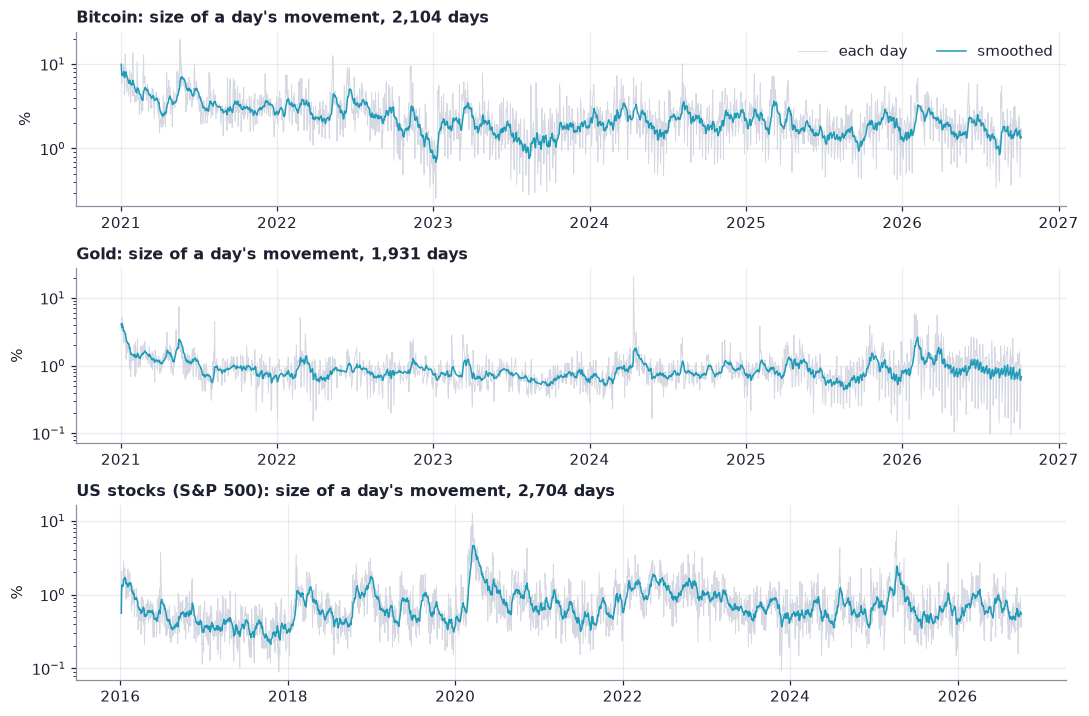

In [2]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(10, 2.2 * len(MARKETS)))
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    ax.plot(days[symbol].index, days[symbol]["rv"] * 100, color="#d5d8e2", lw=0.6, label="each day")
    ax.plot(days[symbol].index, np.exp(days[symbol]["log_rv"]) * 100, color=ACCENT, lw=1, label="smoothed")
    ax.set(title=f"{name}: size of a day's movement, {len(days[symbol]):,} days", ylabel="%", yscale="log")
axes[0].legend(ncol=2)
fig.tight_layout()

The model (a hidden Markov model) assumes the market is always in one of three unseen
states, each with its own usual return and movement, and that a state tends to last.
From the history it works out what the three look like and how they follow each other.

In [3]:
rows = []
for symbol, name in MARKETS.items():
    for state in regime.transition_summary(models[symbol]):
        rows.append(
            {
                "market": name,
                "state": state.label,
                "usual movement in a day, %": state.typical_daily_volatility * 100,
                "usually lasts, days": state.typical_duration_days,
                "usually followed by": max(state.next_states, key=state.next_states.get),
            }
        )
pd.DataFrame(rows).set_index(["market", "state"])

usual movement in a day, %  usually lasts, days usually followed by
market              state                                                                         
Bitcoin             calm                             1.45                36.99              normal
                    normal                           2.23                20.48                calm
                    turbulent                        3.58                33.45              normal
Gold                calm                             0.67                26.63              normal
                    normal                           0.87                15.39                calm
                    turbulent                        1.31                33.90              normal
US stocks (S&P 500) calm                             0.39                33.10              normal
                    normal                           0.60                22.15           turbulent
                    turbulent                        1.10                41.02              normal

### Why three states

A score that rewards fit and charges for complexity (BIC, lower is better) often
prefers four. Three are used anyway so that calm, normal and turbulent mean the same
thing in every market. The table shows what was given up.

In [4]:
pd.DataFrame({MARKETS[s]: models[s].bic_by_states for s in MARKETS}).rename_axis("states").round(0)

,Bitcoin,Gold,US stocks (S&P 500)
states,,,
2,"9,743.00","8,902.00","11,693.00"
3,"8,575.00","7,827.00","9,955.00"
4,"7,687.00","7,252.00","8,706.00"


### The states through time

Price, shaded by the state given **on that day, with no knowledge of later days**.

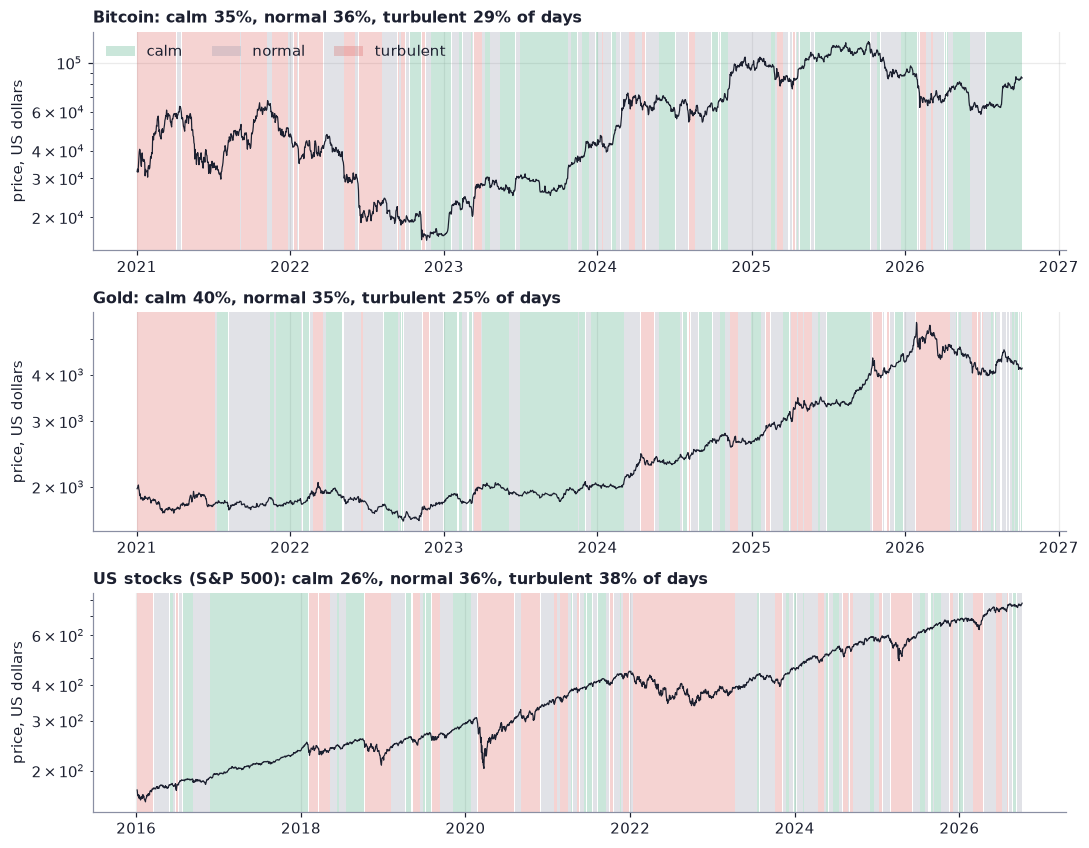

In [5]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(10, 2.6 * len(MARKETS)))
for ax, (symbol, name) in zip(axes, MARKETS.items()):
    labels = regime.filtered_probabilities(models[symbol], days[symbol]).idxmax(axis=1)
    price = closes[symbol].reindex(labels.index).ffill()
    ax.plot(price.index, price.values, color=INK, lw=0.8)
    ax.set_yscale("log")
    low, high = ax.get_ylim()
    for label, colour in STATES.items():
        ax.fill_between(price.index, low, high, where=(labels == label).to_numpy(), color=colour, alpha=0.25, lw=0, label=label)
    share = labels.value_counts(normalize=True)
    spent = ", ".join(f"{label} {share.get(label, 0):.0%}" for label in STATES)
    ax.set(title=f"{name}: {spent} of days", ylim=(low, high), ylabel="price, US dollars")
axes[0].legend(loc="upper left", ncol=3)
fig.tight_layout()

### What hindsight would change

The chance of "turbulent" over the last 250 days, two ways. The dashed line also uses
the days that came after, so it reacts earlier. It looks better and it is cheating:
on the day itself the future was not known. The app only ever uses the solid line.

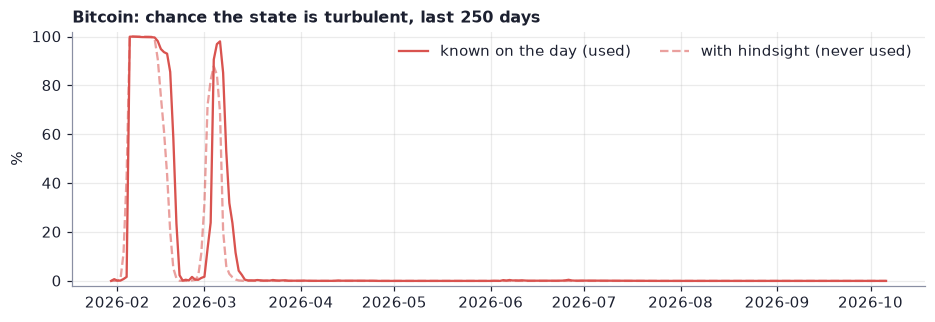

In [6]:
first = next(iter(MARKETS))
known = regime.filtered_probabilities(models[first], days[first])["turbulent"].iloc[-250:]
hindsight = regime.smoothed_probabilities(models[first], days[first])["turbulent"].iloc[-250:]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(known.index, known.values * 100, color=BAD, label="known on the day (used)")
ax.plot(hindsight.index, hindsight.values * 100, color=BAD, ls="--", alpha=0.55, label="with hindsight (never used)")
ax.set(title=f"{MARKETS[first]}: chance the state is turbulent, last 250 days", ylabel="%", ylim=(-2, 102))
ax.legend(ncol=2);

## Step 2. Do the labels mean anything on days the model had not seen?

The model is fitted on history up to a date, then labels the next 63 days it has
never seen; then it is refitted and moves on. Every number below is from those unseen
days. The test: the day **after** a day labelled turbulent should move more than the
day after one labelled calm.

In [7]:
pd.DataFrame(
    {
        MARKETS[s]: {
            "unseen days": check["n_days"],
            "from": check["first_test_day"],
            "to": check["last_test_day"],
            **{f"next day after {label}, %": check["next_day_volatility"][label] * 100 for label in STATES},
            "in the right order": check["volatility_is_ordered"],
            "a state lasts, days": check["average_run_length"],
        }
        for s, check in checks.items()
    }
).T

,unseen days,from,to,"next day after calm, %","next day after normal, %","next day after turbulent, %",in the right order,"a state lasts, days"
Bitcoin,1602,2022-05-17,2026-10-04,1.96,2.71,3.63,True,34.09
Gold,1431,2022-06-24,2026-10-06,0.78,1.01,1.32,True,14.60
US stocks (S&P 500),2202,2017-12-28,2026-10-02,0.54,0.67,1.24,True,21.80


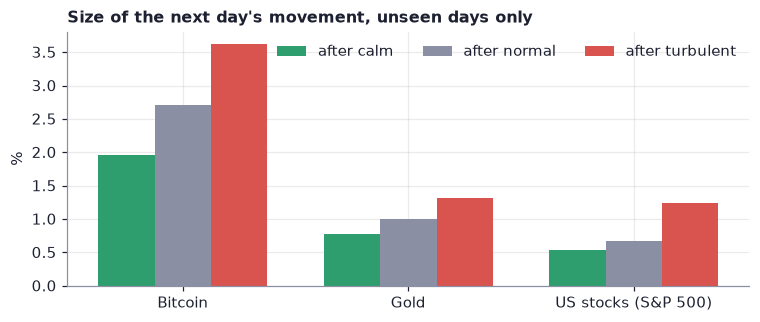

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
width = 0.25
place = np.arange(len(MARKETS))
for index, (label, colour) in enumerate(STATES.items()):
    sizes = [checks[s]["next_day_volatility"][label] * 100 for s in MARKETS]
    ax.bar(place + (index - 1) * width, sizes, width, color=colour, label=f"after {label}")
ax.set(xticks=place, xticklabels=list(MARKETS.values()), ylabel="%", title="Size of the next day's movement, unseen days only")
ax.legend(ncol=3);

### Against a rule with no model

The rival sorts days into three groups by their average movement over the previous
30 days. Both are scored by how well they described each unseen day's return and
movement (average log density, higher is better).

In [9]:
rival = pd.DataFrame(
    {
        MARKETS[s]: {
            "the model": check["model_log_density"],
            "30-day rule": check["baseline_log_density"],
            "model is better": check["model_log_density"] > check["baseline_log_density"],
        }
        for s, check in checks.items()
    }
).T
ordered = sum(check["volatility_is_ordered"] for check in checks.values())
print(f"labels in the right order on unseen days: {ordered} of {len(checks)} markets")
print(f"model better than the 30-day rule: {int(rival['model is better'].sum())} of {len(rival)} markets")
rival

labels in the right order on unseen days: 3 of 3 markets
model better than the 30-day rule: 3 of 3 markets


,the model,30-day rule,model is better
Bitcoin,2.02,1.97,True
Gold,3.66,3.21,True
US stocks (S&P 500),3.18,2.56,True


## Step 3. From today's state to a range of prices

One example market, step by step. First, every past return is sorted by the state of
its day. These are the pools the simulation draws from: real past days, so the
occasional very large move that a bell curve would miss is kept.

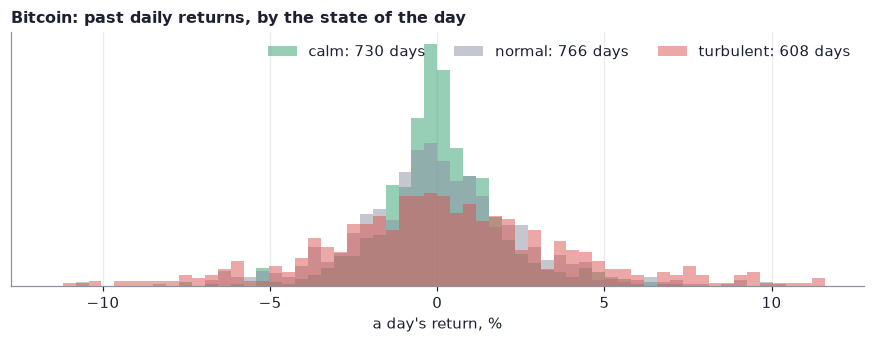

In [10]:
symbol, name, model, run = first, MARKETS[first], models[first], runs[first]
clean = days[symbol].dropna(subset=list(regime.FEATURES))
chances = regime.filtered_probabilities(model, clean).to_numpy()
returns = clean["ret"].to_numpy()
pools, _ = simulator.build_pools(returns, chances.argmax(axis=1), model.n_states)

fig, ax = plt.subplots(figsize=(10, 3))
edge = float(np.quantile(np.abs(returns), 0.995)) * 100
bins = np.linspace(-edge, edge, 61)
for label, pool in zip(model.labels, pools):
    ax.hist(pool * 100, bins=bins, density=True, alpha=0.5, color=STATES[label], label=f"{label}: {len(pool):,} days")
ax.set(title=f"{name}: past daily returns, by the state of the day", xlabel="a day's return, %", yticks=[])
ax.legend(ncol=3);

In [11]:
print("today:", {label: f"{chance:.0%}" for label, chance in zip(model.labels, chances[-1])})
moves = pd.DataFrame(model.transition, index=model.labels, columns=model.labels) * 100
moves.rename_axis("from (row) to (column), % chance in a day").round(1)

today: {'calm': '100%', 'normal': '0%', 'turbulent': '0%'}


,calm,normal,turbulent
"from (row) to (column), % chance in a day",,,
calm,97.30,2.60,0.10
normal,2.70,95.10,2.10
turbulent,0.00,3.00,97.00


Each future starts from today's chances. For every day ahead it draws the next state
from the table above (the large numbers on the diagonal are why states last), then
draws that day's return from the pool for that state.

### The same seed gives the same paths

The app stores each run's random seed. Running again with that seed and the same data
must give exactly the stored paths, or a number on a screen could not be traced.

In [12]:
inputs = simulator.SimulationInputs(chances[-1], np.array(model.transition), pools, returns)
again = simulator.cumulative_returns(simulator.simulate(inputs, 30, n_paths=run["n"], seed=run["seed"]))
gap = float(np.abs(again - run["paths"]).max())
print(f"stored run: as of {run['as_of']:%Y-%m-%d}, seed {run['seed']}, {run['n']:,} paths")
print(f"largest difference between the stored paths and a rerun: {gap}")

stored run: as of 2026-10-07, seed 3724461202, 10,000 paths
largest difference between the stored paths and a rerun: 2.976329760429053e-08


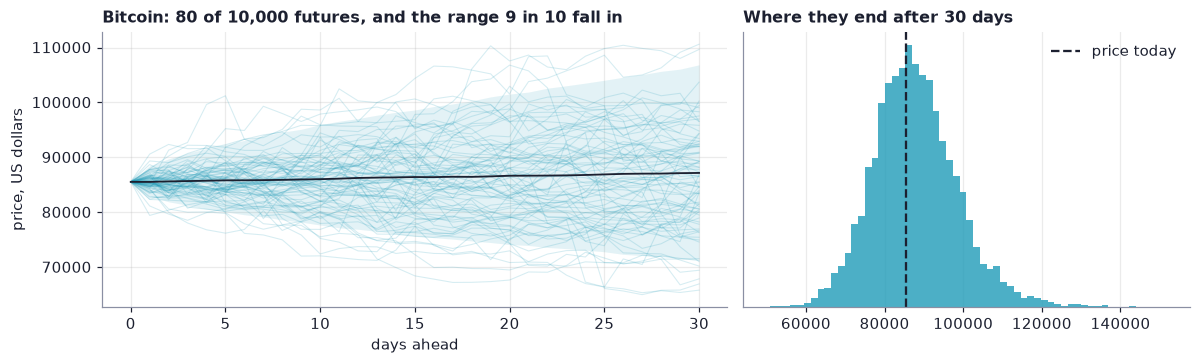

In [13]:
prices = run["price"] * np.exp(run["paths"])
ahead = np.arange(0, prices.shape[1] + 1)
with_start = np.column_stack([np.full(len(prices), run["price"]), prices])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1.4, 1]})
axes[0].plot(ahead, with_start[:80].T, color=ACCENT, alpha=0.18, lw=0.7)
low, middle, high = (np.quantile(with_start, q, axis=0) for q in (0.05, 0.5, 0.95))
axes[0].fill_between(ahead, low, high, color=ACCENT, alpha=0.12, lw=0)
axes[0].plot(ahead, middle, color=INK, lw=1.2)
axes[0].set(title=f"{name}: 80 of {run['n']:,} futures, and the range 9 in 10 fall in", xlabel="days ahead", ylabel="price, US dollars")
axes[1].hist(prices[:, -1], bins=60, color=ACCENT, alpha=0.8)
axes[1].axvline(run["price"], color=INK, ls="--", label="price today")
axes[1].set(title=f"Where they end after {prices.shape[1]} days", yticks=[])
axes[1].legend()
fig.tight_layout()

### Ending above a price is not the same as touching it

"Will it **end** above this price?" and "will it **touch** it at some point?" have
different answers. Touching is always at least as likely.

In [14]:
level = round(run["price"] * 1.10, -2)
reach = pd.DataFrame(
    [simulator.level_probabilities(run["paths"], steps, run["price"], level).model_dump() for steps in (1, 7, 30)]
).set_index("steps")[["level", "ends_above", "touches"]]
reach[["ends_above", "touches"]] *= 100
reach.rename_axis("days ahead").rename(
    columns={"level": "price, 10% above today", "ends_above": "ends above it, %", "touches": "touches it, %"}
)

,"price, 10% above today","ends above it, %","touches it, %"
days ahead,,,
1,"94,100.00",0.03,0.03
7,"94,100.00",4.59,5.75
30,"94,100.00",25.52,40.45


## Step 4. How often did past ranges hold?

For every day after the first 500, with the state model refitted on earlier days
only, the simulation was run and its 50%, 80% and 95% ranges compared with what
happened. "As simulated" is the range as it comes out. "Adjusted" widens the range
after a miss and narrows it after a hit, using earlier results only (adaptive
conformal inference). A range that says 80% should have held about 80% of the time.

In [15]:
held = reports.assign(
    **{"as simulated": reports["empirical"] * 100, "adjusted": reports["empirical_conformal"] * 100}
).pivot_table(index=["market", "horizon_days"], columns="nominal", values=["as simulated", "adjusted"])
held.rename_axis(index=["market", "days ahead"], columns=["", "range says"]).round(1)

adjusted             as simulated            
range says                         0.50  0.80  0.95         0.50  0.80  0.95
market              days ahead                                              
Bitcoin             1             50.40 80.20 94.90        52.50 81.80 95.30
                    7             50.30 80.30 94.70        58.30 83.30 93.60
                    30            49.90 80.30 94.90        57.90 79.50 93.20
Gold                1             49.60 79.70 94.80        45.60 74.30 92.00
                    7             49.60 79.40 94.80        43.50 73.20 90.30
                    30            48.90 79.80 94.70        45.50 71.50 89.50
US stocks (S&P 500) 1             49.90 80.00 95.00        48.40 79.00 94.30
                    7             50.20 80.10 95.00        51.30 81.70 95.50
                    30            50.40 80.50 95.20        53.30 85.00 94.60

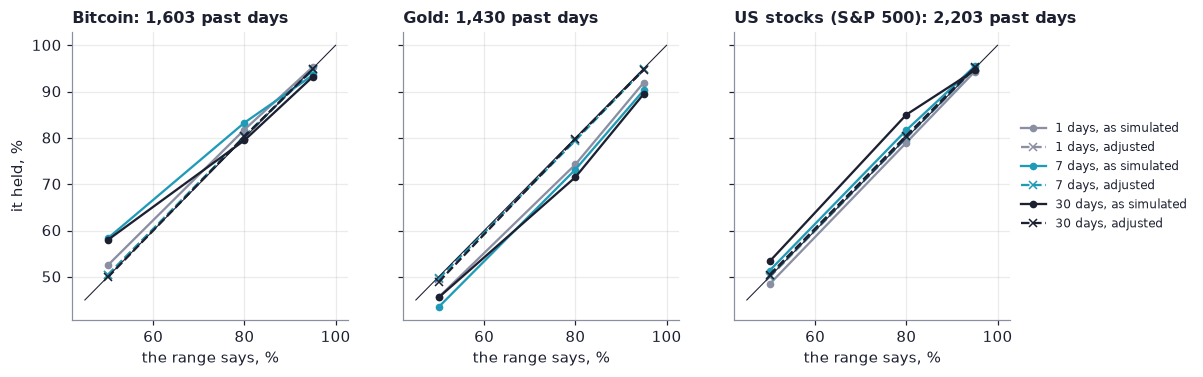

In [16]:
fig, axes = plt.subplots(1, len(MARKETS), figsize=(11, 3.4), sharey=True)
shades = {1: MUTED, 7: ACCENT, 30: INK}
for ax, name in zip(axes, MARKETS.values()):
    group = reports[reports["market"] == name]
    for horizon, part in group.groupby("horizon_days"):
        part = part.sort_values("nominal")
        colour = shades.get(int(horizon), INK)
        ax.plot(part["nominal"] * 100, part["empirical"] * 100, marker="o", ms=4, color=colour, label=f"{horizon} days, as simulated")
        ax.plot(part["nominal"] * 100, part["empirical_conformal"] * 100, marker="x", ms=5, ls="--", color=colour, label=f"{horizon} days, adjusted")
    ax.plot([45, 100], [45, 100], color=INK, lw=0.7)
    ax.set(title=f"{name}: {int(group['n'].max()):,} past days", xlabel="the range says, %")
axes[0].set(ylabel="it held, %")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8);

In [17]:
# The claim in the summary, checked: how far off the stated figure each kind of range was.
off = reports.assign(
    simulated=(reports["empirical"] - reports["nominal"]).abs() * 100,
    adjusted=(reports["empirical_conformal"] - reports["nominal"]).abs() * 100,
)
print(f"ranges checked: {len(off)}")
print(f"average distance from the stated figure, as simulated: {off['simulated'].mean():.1f} points")
print(f"average distance from the stated figure, adjusted:     {off['adjusted'].mean():.1f} points")
print(f"worst, as simulated: {off['simulated'].max():.1f} points; adjusted: {off['adjusted'].max():.1f} points")
print(f"adjusted is closer in {int((off['adjusted'] < off['simulated']).sum())} of {len(off)}")

ranges checked: 27
average distance from the stated figure, as simulated: 3.4 points
average distance from the stated figure, adjusted:     0.3 points
worst, as simulated: 8.5 points; adjusted: 1.1 points
adjusted is closer in 27 of 27


Points on the straight line held exactly as often as stated. Above it the range was
too wide; below it, too narrow.

### Against a simple forecast

The rival assumes a random walk whose movement is the last year's average. Both are
scored with a standard error for ranges (pinball loss, lower is better).

In [18]:
score = reports.drop_duplicates(["symbol", "horizon_days"])[["market", "horizon_days", "n", "pinball_model", "pinball_baseline"]].copy()
score["difference, %"] = (score["pinball_model"] / score["pinball_baseline"] - 1) * 100
print(f"simulation has the smaller error in {int((score['difference, %'] < 0).sum())} of {len(score)}")
score.rename(
    columns={"horizon_days": "days ahead", "n": "past days", "pinball_model": "simulation", "pinball_baseline": "simple forecast"}
).set_index(["market", "days ahead"]).style.format({"difference, %": "{:+.1f}", "simulation": "{:.5f}", "simple forecast": "{:.5f}"})

simulation has the smaller error in 5 of 9


A negative difference means the simulation's error was smaller. Where it is not, the
app says so beside the range.

## What to take from this

- The counts printed under steps 2 and 4 are the results. The labels are worth
  showing in a market only where they came out in the right order on unseen days.
- A state is found **after** it begins. The label describes the present and does not
  call turning points.
- The simulation assumes the future resembles the past it draws from. A kind of move
  that has never happened in the data cannot appear in it.
- Bitcoin and gold (followed as PAX Gold) start in 2021, so their states are learned
  from few market cycles.